In [1]:


import tensorflow as tf
from tensorflow.keras import layers,models
import matplotlib.pyplot as plt 
from tensorflow.keras import preprocessing
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"



In [2]:
IMAGE_SIZE= 256
BATCH_SIZE= 32
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    r"C:\Users\acer\Downloads\archive (6)\PlantVillage",#direectory
    shuffle=True,
    
    image_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size= BATCH_SIZE

)

Found 2152 files belonging to 3 classes.


In [3]:
potato = dataset.class_names
potato

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

(32, 256, 256, 3)
[0 0 1 1 1 1 1 1 1 0 0 0 1 1 0 1 1 1 1 0 0 0 1 0 1 2 0 0 0 0 1 1]
(32,)


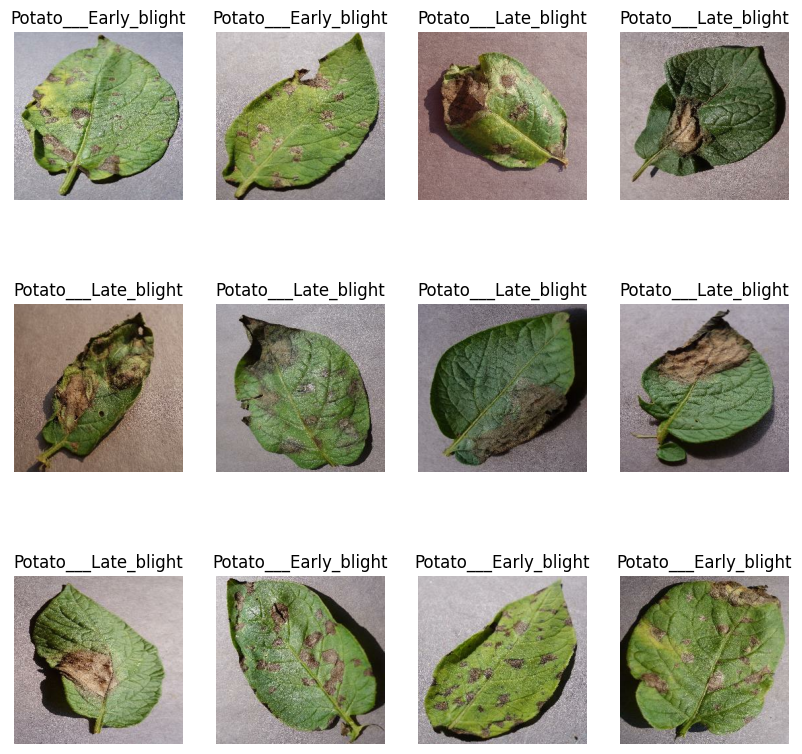

In [4]:
plt.figure(figsize=(10,10))
for image_batch, label_batch in dataset.take(1): #it takes the argument from dataset 
    print(image_batch.shape)
    print(label_batch.numpy())## we are using the labels in numpy as they refrer to the indexes
    print(label_batch.shape)  #the tf.dataset is a lot of 32 images or the batch size is 32 so when we take it takes 1 lot of 32 images 
    for i in range(12):
        plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(potato[label_batch[i]])
        plt.axis("off")

In [5]:
train_size = 0.8
len(dataset)*train_size

54.400000000000006

In [6]:
train_ds = dataset.take(54)
len(train_ds)

54

In [7]:
test_ds = dataset.take(14)
len(test_ds)

14

In [8]:
val_size = 0.1

test_val = test_ds.take(6)
len(test_val)

6

In [9]:
test_ds = test_ds.skip(6)

In [10]:
def get_dataset_partitions_tf(ds,train_split =0.8, val_split = 0.1,test_split = 0.1,shuffle = True,shuffle_size = 1):
    ds_size = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed =12)

    train_size = int(train_split*ds_size)
    val_size = int(val_split*ds_size)

    train_ds = ds.take(train_size)

    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    
    return train_ds, val_ds,test_ds

In [11]:
train_ds,val_ds,test_ds = get_dataset_partitions_tf(dataset) # we are passinf the dataset onto the function and after it i'll get the train and all datasset

In [12]:
len(train_ds)

54

In [13]:
train_ds= train_ds.cache().shuffle(1000).prefetch(buffer_size= tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size= tf.data.AUTOTUNE)

In [14]:
resize_and_reshape = tf.keras.Sequential([
    layers.Resizing( IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1.0/255)
])

In [15]:
data_augmentation= tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)


    
])

In [31]:
n_classes = 3



model = models.Sequential([
    resize_and_reshape,
    data_augmentation,
    
    layers.Conv2D(32,(3,3), activation= 'relu', input_shape= (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, kernel_size = (3,3),activation = 'relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, kernel_size = (3,3),activation = 'relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation = 'relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, kernel_size = (3,3),activation = 'relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation = 'relu'),
    layers.Dense(n_classes,activation = 'softmax') #this is the final step which gives the probability
    
    
    
])
model.build(input_shape=(BATCH_SIZE,IMAGE_SIZE,IMAGE_SIZE,3))

In [32]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (32, 256, 256, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_1 (Sequential)            │ (32, 256, 256, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (32, 254, 254, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (32, 127, 127, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (32, 125, 125, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (32, 62, 62, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (32, 60, 60, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (32, 30, 30, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (32, 28, 28, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (32, 14, 14, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (32, 12, 12, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (32, 6, 6, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (32, 2304)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (32, 64)                    │         147,520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (32, 3)                     │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 277,891 (1.06 MB)

 Trainable params: 277,891 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
model.compile(
    optimizer = 'adam',
    loss= tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics = ['accuracy']
)


In [34]:
history = model.fit(
    train_ds,
    steps_per_epoch=5,
    epochs=40,
    batch_size = BATCH_SIZE,
    validation_data= val_ds
)

Epoch 1/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.5375 - loss: 0.9560 - val_accuracy: 0.5260 - val_loss: 0.8474
Epoch 2/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.4688 - loss: 0.9440 - val_accuracy: 0.5677 - val_loss: 0.8596
Epoch 3/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.4625 - loss: 0.9676 - val_accuracy: 0.6042 - val_loss: 0.8877
Epoch 4/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.5562 - loss: 0.8648 - val_accuracy: 0.5260 - val_loss: 0.9821
Epoch 5/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.4875 - loss: 0.9012 - val_accuracy: 0.4323 - val_loss: 0.8696
Epoch 6/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.4750 - loss: 0.8810 - val_accuracy: 0.4219 - val_loss: 0.8739
Epoch 7/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.5188 - loss: 0.8924 - val_accuracy: 0.5260 - val_loss: 0.7941
Epoch 8/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.4062 - loss: 0.9115 - val_accuracy: 0.5260 - val_loss: 0.7622
Epoch 9/

In [35]:
y_pred = model.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 879ms/step - accuracy: 0.8750 - loss: 0.2924


In [36]:
history


In [23]:
history.params

{'verbose': 'auto', 'epochs': 3, 'steps': 54}

In [24]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [37]:
acc=  history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

first image to predict
first image's actual label: Potato___Late_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 536ms/step
[6.6640951e-02 9.3335903e-01 5.9052536e-09]
1


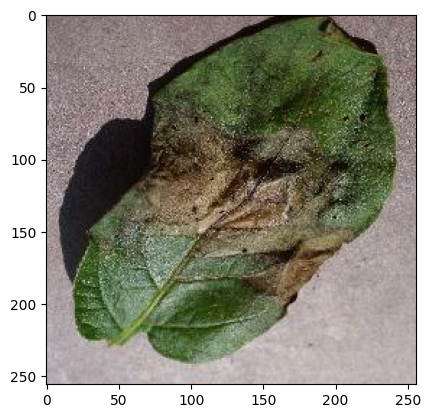

In [60]:
import numpy 
for image_batch, labels_batch in test_ds.take(1):

    first_image = image_batch[0].numpy().astype("uint8")
    first_label = labels_batch[0].numpy()

    print("first image to predict")
    plt.imshow(first_image)
    print("first image's actual label:", potato[first_label])

    batch_prediction=model.predict(image_batch)
    print(batch_prediction[0])
    print(numpy.argmax(batch_prediction[0]))
# as you can see we are getting a three dimension array and that is because of the the n_classes or neurons in the architecture which was three


In [39]:
def predict(model,img):
    img_array = tf.keras.preprocessing.image.img_to_array(img.numpy())
    img_array = tf.expand_dims(img_array, 0) #create a batch

    predictions = model.predict(img_array)

    predicted_class = potato[numpy.argmax(predictions[0])]
    confidence = round(100* (numpy.max(predictions[0])),2)
    return predicted_class,confidence


    

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


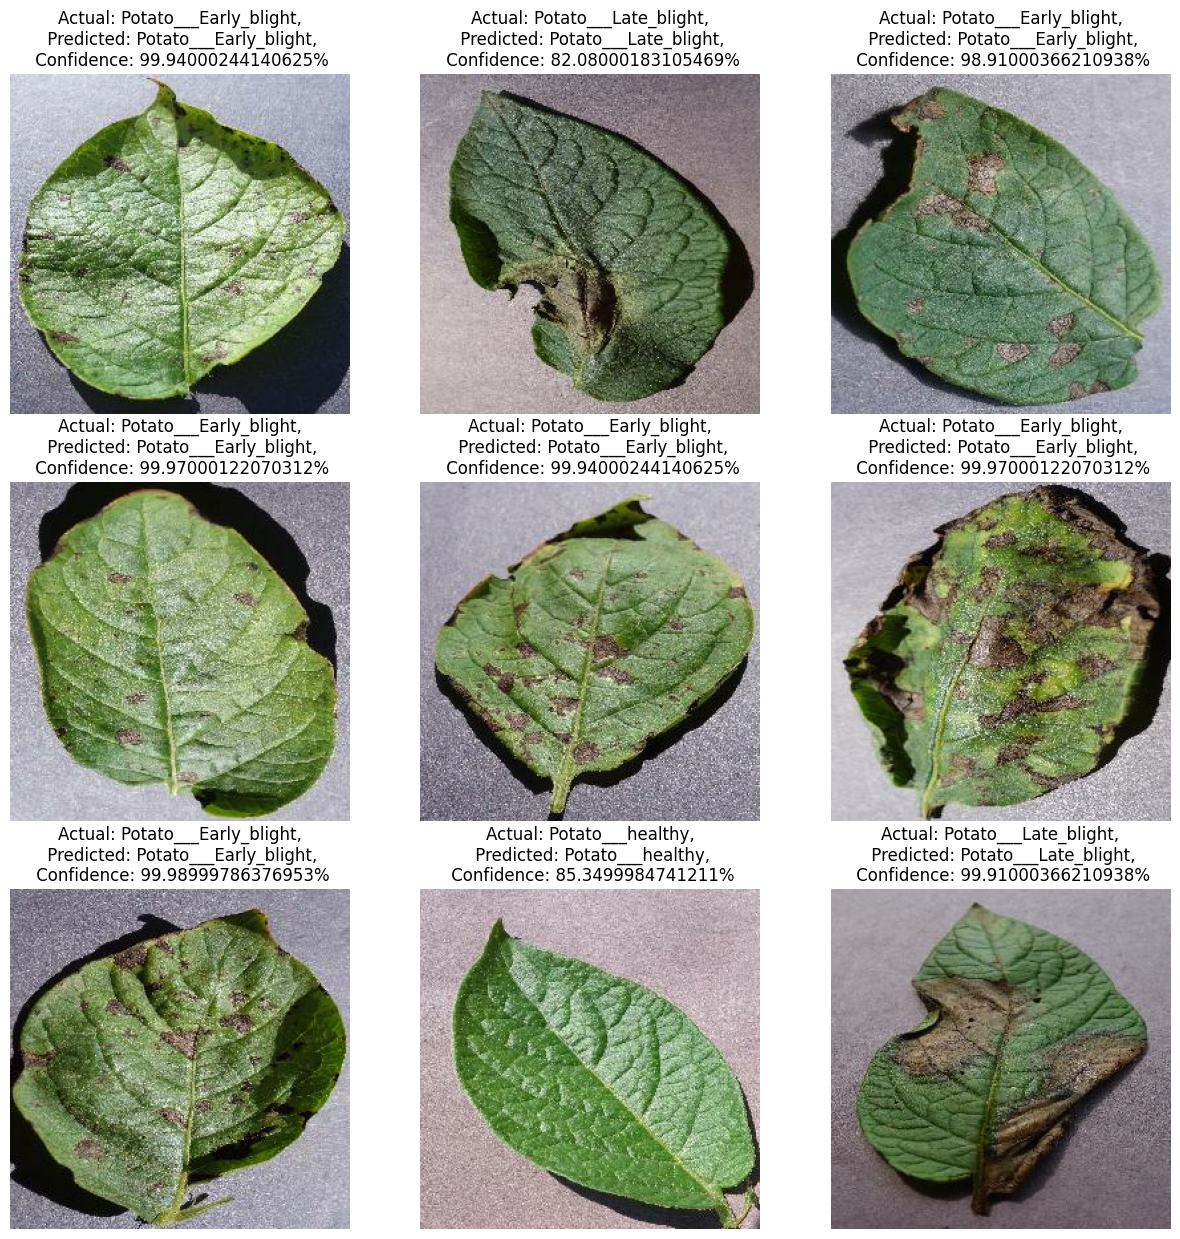

In [40]:

plt.figure(figsize=(15,15))
for images,labels in test_ds.take(1):
    for i in range(9):
        ax= plt.subplot(3,3, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_class,confidence = predict(model,images[i]) ##from here the params are passed on to the predict function and based on it we got the class and confidence
        actual_class = potato[labels[i]]
        
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class},\n Confidence: {confidence}%")
        plt.axis("off")
        

In [42]:
model_version=3
model_name = f"model_{model_version}.keras"
model.save(model_name)

In [44]:
model_version = 3
model.save(f"../model/{model_version}.keras")   ## we have used the .. as we in potato disease directory model folder is one step above the training and namse is model

In [66]:
import os
max([int(i) for i in os.listdir("../model")+ [0]]) + 1

ValueError: invalid literal for int() with base 10: '1.keras'